In [113]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import rasterio
import tifffile
import skimage
from matplotlib import pyplot as plt
from tqdm import tqdm
import cv2
import higra as hg
import torch
import pickle

In [114]:
# https://github.com/waldnerf/decode/blob/main/postprocessing/instance_segmentation.py
def watershed(input_hws, t_bound):
    # Create the directed graph
    size = input_hws.shape[:2]
    graph = hg.get_8_adjacency_graph(size)
    edge_weights = hg.weight_graph(
        graph,
        input_hws,
        hg.WeightFunction.mean)

    tree, altitudes = hg.watershed_hierarchy_by_dynamics(
        graph,
        edge_weights)
    
    # Get individual fields
    # by cutting the graph using altitude
    instances = hg.labelisation_horizontal_cut_from_threshold(
        tree,
        altitudes,
        threshold=t_bound).astype(float)
    return instances

In [115]:
# https://stackoverflow.com/questions/66595055/fastest-way-of-computing-binary-mask-iou-with-numpy
def iou(mask1, mask2):
    intersection = (mask1 * mask2).sum()
    if intersection == 0:
        return 0.0
    union = torch.logical_or(mask1, mask2).to(torch.int).sum()
    return intersection / union

In [116]:
import itertools
def compute_pair_to_iou_dict(masks):
    indices = np.arange(len(masks))
    pairs = itertools.combinations(indices, 2)
    pair_to_iou = {}
    for pair in pairs:
        i, j = pair
        pair_to_iou[tuple(pair)] = iou(masks[i], masks[j]).numpy()
    return pair_to_iou

# Helper functions for conformal algorithm

In [123]:
def compute_T_confidence_set(IOUs, T_values, alpha, IOU_threshold):
    IOUs_high = (IOUs>IOU_threshold).astype(int)
    T_confidence_set = []
    num_calibration_pixels_covered = 0
    num_calibration_pixels_target = (1-alpha)*len(results_table)
    while num_calibration_pixels_covered < num_calibration_pixels_target:
        coverage_by_T = IOUs_high.sum(axis=0)
        best_T = np.argmax(coverage_by_T)
        calibration_pixels_covered = np.argwhere(IOUs_high[:, best_T]==1)
        IOUs_high = np.delete(IOUs_high, calibration_pixels_covered, axis=0)
        
        T_confidence_set.append(best_T)
        num_calibration_pixels_covered += np.max(coverage_by_T)
    
    T_confidence_set = T_values[np.sort(T_confidence_set)]
    print("Greedy algorithm output:", T_confidence_set)
    return T_confidence_set

def compute_pair_ious(results_table, Ts, save_filename):
    pair_to_iou_dicts = []
    IOUs = []
    for index, row in tqdm(results_table.iterrows(), total=results_table.shape[0]):
        image_number = row["image_number"]
        coord = row["coord"]
        true_segmentation = rasterio.open(os.path.join('../data/ftw/france/label_masks/instance', image_number+'.tif')).read()[0]
        true_field = true_segmentation==true_segmentation[coord]
        pred_probability = rasterio.open(os.path.join('../data/ftw_predictions/france_test/predictions_3class/probability', image_number+'.tif')).read()[2]
        pred_shapes_coord = []
        IOUs_coord = []
    
        size = pred_probability.shape[:2]
        graph = hg.get_8_adjacency_graph(size)
        edge_weights = hg.weight_graph(
            graph,
            pred_probability,
            hg.WeightFunction.mean)
        tree, altitudes = hg.watershed_hierarchy_by_dynamics(
            graph,
            edge_weights)
    
        for T in Ts:
            pred_segmentation = hg.labelisation_horizontal_cut_from_threshold(tree,altitudes,threshold=T).astype(float)
            pred_field = pred_segmentation==pred_segmentation[coord]
            IOU = iou(torch.from_numpy(true_field), torch.from_numpy(pred_field))
            pred_shapes_coord.append(torch.from_numpy(pred_field))
            IOUs_coord.append(IOU)
        
        pair_to_iou_dicts.append(compute_pair_to_iou_dict(pred_shapes_coord))
        IOUs.append(IOUs_coord)
    
    results_table["Pred Mask Pair to IOUs"] = pair_to_iou_dicts
    results_table["IOUs"] = IOUs
    
    file = open(f'results/field-delineation-{save_filename}.pkl', 'wb')
    pickle.dump(results_table, file)
    file.close()

def remove_duplicate_masks_asymptotic(indices, pair_to_iou, iou_threshold=0.95):
    for k in np.arange(1, len(indices)+1):
        for new_indices in itertools.combinations(indices, k):
            removed_indices = list(set(indices) - set(new_indices))
            valid_combination = True
            for i in removed_indices:
                new_indices_contain_similar_mask = False
                for j in new_indices:
                    if pair_to_iou[tuple(sorted((i, j)))] > iou_threshold:
                        new_indices_contain_similar_mask = True
                        break
                if not new_indices_contain_similar_mask:
                    valid_combination = False
                    break
            if valid_combination:
                return list(new_indices)

def compute_final_results_asymptotic(save_filename, alpha, IOU_threshold_duplicate_mask):
    file = open(f'results/field-delineation-{save_filename}-calibration.pkl', 'rb')
    results_table = pickle.load(file)
    file.close()
    max_confidence_set_size = len(np.array(results_table['IOUs'])[0])
    indices = np.arange(max_confidence_set_size)
    results_table["Final Mask Indices"] = results_table["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_asymptotic(indices, x, iou_threshold=IOU_threshold_duplicate_mask))
    results_table["Final Mask Number"] = results_table["Final Mask Indices"].apply(lambda x: len(x))
    results_table["Final Mask IOUs"] = results_table.apply(lambda x: np.array(x["IOUs"])[x["Final Mask Indices"]], axis=1)
    results_table["Final Mask max IOU"] = results_table["Final Mask IOUs"].map(lambda x: np.max(x))
    new_IOU_threshold = np.quantile(results_table["Final Mask max IOU"], alpha)

    file = open(f'results/field-delineation-{save_filename}-test.pkl', 'rb')
    results_table_test = pickle.load(file)
    file.close()
    results_table_test["Final Mask Indices"] = results_table_test["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_asymptotic(indices, x, iou_threshold=IOU_threshold_duplicate_mask))
    results_table_test["Final Mask Number"] = results_table_test["Final Mask Indices"].apply(lambda x: len(x))
    results_table_test["Final Mask IOUs"] = results_table_test.apply(lambda x: np.array(x["IOUs"])[x["Final Mask Indices"]], axis=1)
    results_table_test["Final Mask max IOU"] = results_table_test["Final Mask IOUs"].map(lambda x: np.max(x))
    results_table_test_high_IOUs = results_table_test[results_table_test["Final Mask max IOU"] > new_IOU_threshold]
    coverage = len(results_table_test_high_IOUs) / len(results_table_test)
    avg_confidence_set_size = np.mean(results_table_test["Final Mask Number"])

    return new_IOU_threshold, coverage, max_confidence_set_size, avg_confidence_set_size

# Varying alpha

In [7]:
#alpha = 0.2
IOU_threshold = 0.7
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
IOU_threshold_duplicate_mask = 0.9

alpha_list = [0.2, 0.25, 0.3, 0.35]

In [8]:
for i, alpha in enumerate(alpha_list):
    file = open('../data/ftw_predictions/france_test/conformal_ious_more_T_values.pkl', 'rb')
    results_table = pickle.load(file)
    file.close()
    IOUs = np.array([np.array(x) for x in results_table["IOUs"]])
    results_table = results_table[['image_number', 'coord']]

    file = open('../data/ftw_predictions/france_test/conformal_ious_test_with_pairwise_IOUs_more_T_values.pkl', 'rb')
    results_table_test = pickle.load(file)
    file.close()
    results_table_test = results_table_test[['image_number', 'coord']]

    save_filename = f'alpha-{i}'
    T_confidence_set = compute_T_confidence_set(IOUs, T_values, alpha, IOU_threshold)
    compute_pair_ious(results_table, T_confidence_set, save_filename+'-calibration')
    compute_pair_ious(results_table_test, T_confidence_set, save_filename+'-test')

Greedy algorithm output: [0.001 0.06  0.24  0.35  0.58  0.69 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [02:42<00:00,  5.64it/s]


Greedy algorithm output: [0.001 0.24  0.58 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [02:20<00:00,  6.52it/s]


Greedy algorithm output: [0.001 0.24 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [02:04<00:00,  7.34it/s]


Greedy algorithm output: [0.24]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [02:03<00:00,  7.45it/s]


In [46]:
new_IOU_thresholds = []
coverages = []
max_confidence_set_sizes = []
avg_confidence_set_sizes = []

for i, alpha in enumerate(alpha_list):
    save_filename = f'alpha-{i}'
    new_IOU_threshold, coverage, max_confidence_set_size, avg_confidence_set_size = compute_final_results_asymptotic(save_filename, alpha, IOU_threshold_duplicate_mask) 

    new_IOU_thresholds.append(new_IOU_threshold)
    coverages.append(coverage)
    max_confidence_set_sizes.append(max_confidence_set_size)
    avg_confidence_set_sizes.append(avg_confidence_set_size)

print(new_IOU_thresholds)
print(coverages)
print(max_confidence_set_sizes)
print(avg_confidence_set_sizes)

results = [alpha_list, new_IOU_thresholds, coverages, max_confidence_set_sizes, avg_confidence_set_sizes]
file = open(f'results/results-alpha.pkl', 'wb')
pickle.dump(results, file)
file.close()

[np.float32(0.70469606), np.float32(0.7282828), np.float32(0.7389373), np.float32(0.7282828)]
[0.7764449291166848, 0.7295528898582334, 0.6957470010905126, 0.6292257360959651]
[6, 3, 2, 1]
[np.float64(2.9051254089422027), np.float64(2.0381679389312977), np.float64(1.6564885496183206), np.float64(1.0)]


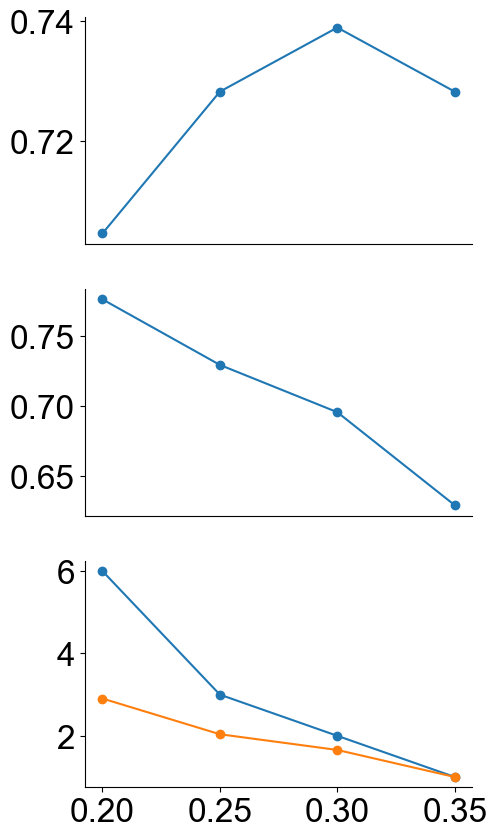

In [47]:
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(5, 10))

x = np.array(alpha_list)
sort_idx = np.argsort(x)

y = np.array(new_IOU_thresholds)
axs[0].plot(x[sort_idx], y[sort_idx], marker='o')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].xaxis.set_visible(False)

y = np.array(coverages)
axs[1].plot(x[sort_idx], y[sort_idx], marker='o')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].xaxis.set_visible(False)

y = np.array(max_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='max')
y = np.array(avg_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='average')
#plt.legend()
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_xticks(np.arange(0.2, 0.4, 0.05))
plt.show()

# Varying tau (IOU threshold)

In [163]:
alpha = 0.2
#IOU_threshold = 0.7
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
IOU_threshold_duplicate_mask = 0.9

tau_list = [0.65, 0.6, 0.5]

In [9]:
for i, IOU_threshold in enumerate(tau_list):
    file = open('../data/ftw_predictions/france_test/conformal_ious_more_T_values.pkl', 'rb')
    results_table = pickle.load(file)
    file.close()
    IOUs = np.array([np.array(x) for x in results_table["IOUs"]])
    results_table = results_table[['image_number', 'coord']]

    file = open('../data/ftw_predictions/france_test/conformal_ious_test_with_pairwise_IOUs_more_T_values.pkl', 'rb')
    results_table_test = pickle.load(file)
    file.close()
    results_table_test = results_table_test[['image_number', 'coord']]

    save_filename = f'tau-{i}'
    T_confidence_set = compute_T_confidence_set(IOUs, T_values, alpha, IOU_threshold)
    compute_pair_ious(results_table, T_confidence_set, save_filename+'-calibration')
    compute_pair_ious(results_table_test, T_confidence_set, save_filename+'-test')

Greedy algorithm output: [0.001 0.26  0.58 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [02:41<00:00,  5.67it/s]


Greedy algorithm output: [0.001 0.23 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [02:08<00:00,  7.15it/s]


Greedy algorithm output: [0.3]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [02:00<00:00,  7.61it/s]


In [11]:
new_IOU_thresholds = []
coverages = []
max_confidence_set_sizes = []
avg_confidence_set_sizes = []

for i, IOU_threshold in enumerate(tau_list):
    save_filename = f'tau-{i}'
    new_IOU_threshold, coverage, max_confidence_set_size, avg_confidence_set_size = compute_final_results_asymptotic(save_filename, alpha, IOU_threshold_duplicate_mask) 

    new_IOU_thresholds.append(new_IOU_threshold)
    coverages.append(coverage)
    max_confidence_set_sizes.append(max_confidence_set_size)
    avg_confidence_set_sizes.append(avg_confidence_set_size)

# include results from "alpha-0" experiment
results = [[0.7]+tau_list, [0.70469606]+new_IOU_thresholds, [0.7764449291166848]+coverages, [6]+max_confidence_set_sizes, [2.9051254089422027]+avg_confidence_set_sizes]
file = open(f'results/results-tau.pkl', 'wb')
pickle.dump(results, file)
file.close()

for l in results:
    print(l)

[0.7, 0.65, 0.6, 0.5]
[0.70469606, np.float32(0.66746265), np.float32(0.6078564), np.float32(0.53477824)]
[0.7764449291166848, 0.7797164667393675, 0.787350054525627, 0.7262813522355507]
[6, 3, 2, 1]
[2.9051254089422027, np.float64(2.0261723009814614), np.float64(1.6499454743729554), np.float64(1.0)]


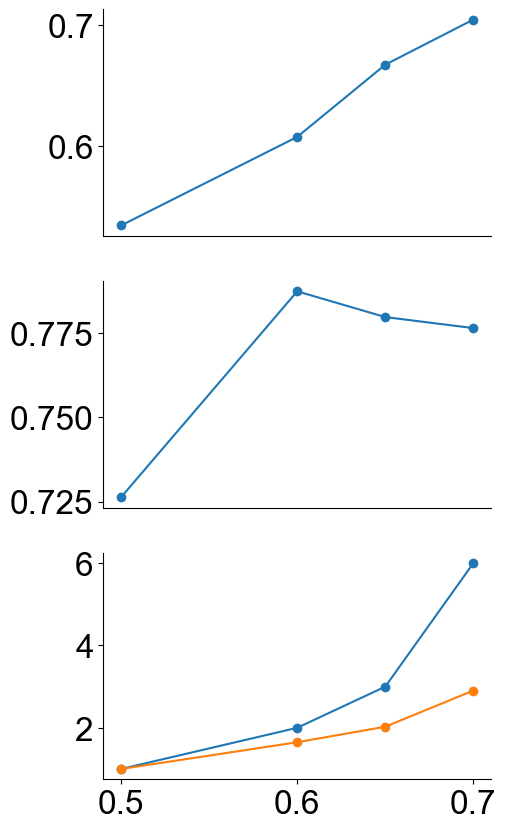

In [13]:
file = open('results/results-tau.pkl', 'rb')
results = pickle.load(file)
file.close()
tau_list, new_IOU_thresholds, coverages, max_confidence_set_sizes, avg_confidence_set_sizes = results

plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(5, 10))

x = np.array(tau_list)
sort_idx = np.argsort(x)

y = np.array(new_IOU_thresholds)
axs[0].plot(x[sort_idx], y[sort_idx], marker='o')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].xaxis.set_visible(False)

y = np.array(coverages)
axs[1].plot(x[sort_idx], y[sort_idx], marker='o')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].xaxis.set_visible(False)

y = np.array(max_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='max')
y = np.array(avg_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='average')
#plt.legend()
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_xticks(np.arange(0.5, 0.75, 0.1))
plt.show()

# Varying k (number of T values)

In [71]:
alpha = 0.2
IOU_threshold = 0.7
#T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
IOU_threshold_duplicate_mask = 0.9

T_values_original = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
T_values_indices_1 = np.concatenate([np.arange(1, 9, 2), np.arange(9, 110, 2)])
T_values_indices_2 = np.concatenate([np.arange(4, 9, 5), np.arange(9, 110, 5)])
T_values_indices_3 = np.arange(9, 110, 10)
T_values_indices_list = [T_values_indices_1, T_values_indices_2, T_values_indices_3]
T_values_list = [T_values_original[idx] for idx in T_values_indices_list]
k_list = [len(l) for l in T_values_list]

for l in T_values_list:
    print(l)
print(k_list)

[0.002 0.004 0.006 0.008 0.    0.02  0.04  0.06  0.08  0.1   0.12  0.14
 0.16  0.18  0.2   0.22  0.24  0.26  0.28  0.3   0.32  0.34  0.36  0.38
 0.4   0.42  0.44  0.46  0.48  0.5   0.52  0.54  0.56  0.58  0.6   0.62
 0.64  0.66  0.68  0.7   0.72  0.74  0.76  0.78  0.8   0.82  0.84  0.86
 0.88  0.9   0.92  0.94  0.96  0.98  1.   ]
[0.005 0.    0.05  0.1   0.15  0.2   0.25  0.3   0.35  0.4   0.45  0.5
 0.55  0.6   0.65  0.7   0.75  0.8   0.85  0.9   0.95  1.   ]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[55, 22, 11]


In [72]:
for i, T_values in enumerate(T_values_list):
    file = open('../data/ftw_predictions/france_test/conformal_ious_more_T_values.pkl', 'rb')
    results_table = pickle.load(file)
    file.close()
    IOUs = np.array([np.array(x) for x in results_table["IOUs"]])
    IOUs = IOUs[:, T_values_indices_list[i]]
    results_table = results_table[['image_number', 'coord']]

    file = open('../data/ftw_predictions/france_test/conformal_ious_test_with_pairwise_IOUs_more_T_values.pkl', 'rb')
    results_table_test = pickle.load(file)
    file.close()
    results_table_test = results_table_test[['image_number', 'coord']]

    save_filename = f'k-{i}'
    p = 1 - np.sum(np.max(IOUs, axis=1) > IOU_threshold) / len(IOUs)
    if p > alpha: 
        print("No set of parameters will allow us to meet the IOU threshold")
        T_confidence_set = T_values
    else:
        T_confidence_set = compute_T_confidence_set(IOUs, T_values, alpha, IOU_threshold)
    compute_pair_ious(results_table, T_confidence_set, save_filename+'-calibration')
    compute_pair_ious(results_table_test, T_confidence_set, save_filename+'-test')

Greedy algorithm output: [0.002 0.06  0.24  0.36  0.58  0.66 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [03:09<00:00,  4.83it/s]


Greedy algorithm output: [0.005 0.05  0.1   0.15  0.3   0.35  0.4   0.45  0.55  0.6   0.65  0.7
 0.75  0.8  ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [05:21<00:00,  2.86it/s]


No set of parameters will allow us to meet the IOU threshold


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [04:48<00:00,  3.18it/s]


In [79]:
new_IOU_thresholds = []
coverages = []
max_confidence_set_sizes = []
avg_confidence_set_sizes = []

for i, T_values in enumerate(T_values_list):
    save_filename = f'k-{i}'
    new_IOU_threshold, coverage, max_confidence_set_size, avg_confidence_set_size = compute_final_results_asymptotic(save_filename, alpha, IOU_threshold_duplicate_mask) 

    new_IOU_thresholds.append(new_IOU_threshold)
    coverages.append(coverage)
    max_confidence_set_sizes.append(max_confidence_set_size)
    avg_confidence_set_sizes.append(avg_confidence_set_size)

# include results from "alpha-0" experiment
results = [[110]+k_list, [0.70469606]+new_IOU_thresholds, [0.7764449291166848]+coverages, [6]+max_confidence_set_sizes, [2.9051254089422027]+avg_confidence_set_sizes]
file = open(f'results/results-k.pkl', 'wb')
pickle.dump(results, file)
file.close()

for l in results:
    print(l)

[110, 55, 22, 11]
[0.70469606, np.float32(0.6960648), np.float32(0.6960648), np.float32(0.6339625)]
[0.7764449291166848, 0.7906215921483097, 0.8146128680479825, 0.7688113413304253]
[6, 6, 14, 11]
[2.9051254089422027, np.float64(2.669574700109051), np.float64(4.563794983642312), np.float64(4.738276990185387)]


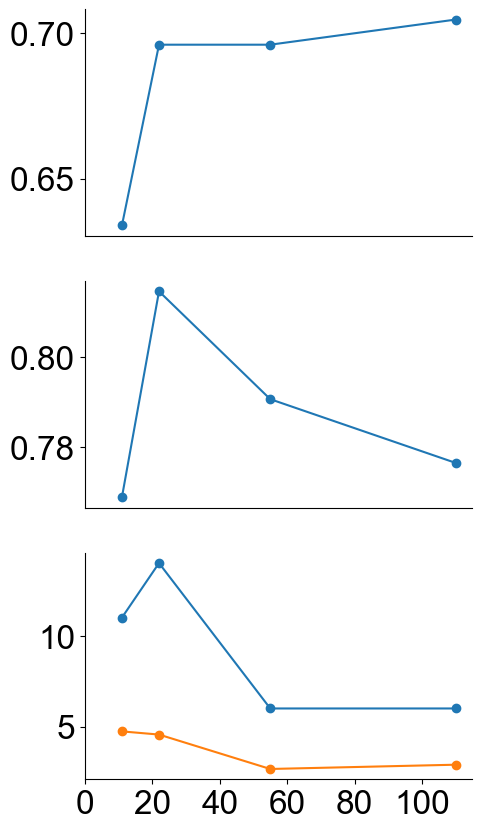

In [82]:
file = open('results/results-k.pkl', 'rb')
results = pickle.load(file)
file.close()
k_list, new_IOU_thresholds, coverages, max_confidence_set_sizes, avg_confidence_set_sizes = results

plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(5, 10))

x = np.array(k_list)
sort_idx = np.argsort(x)

y = np.array(new_IOU_thresholds)
axs[0].plot(x[sort_idx], y[sort_idx], marker='o')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].xaxis.set_visible(False)

y = np.array(coverages)
axs[1].plot(x[sort_idx], y[sort_idx], marker='o')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].xaxis.set_visible(False)

y = np.array(max_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='max')
y = np.array(avg_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='average')
#plt.legend()
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_xticks(np.arange(0, 120, 20))
plt.show()

# Varying eta (IOU threshold for duplicate masks)

In [83]:
alpha = 0.2
IOU_threshold = 0.7
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
#IOU_threshold_duplicate_mask = 0.9

eta_list = [0.7, 0.8, 0.95]

In [84]:
new_IOU_thresholds = []
coverages = []
max_confidence_set_sizes = []
avg_confidence_set_sizes = []

for i, IOU_threshold_duplicate_mask in enumerate(eta_list):
    # use results from "alpha-0" experiment
    save_filename = 'alpha-0'
    new_IOU_threshold, coverage, max_confidence_set_size, avg_confidence_set_size = compute_final_results_asymptotic(save_filename, alpha, IOU_threshold_duplicate_mask) 

    new_IOU_thresholds.append(new_IOU_threshold)
    coverages.append(coverage)
    max_confidence_set_sizes.append(max_confidence_set_size)
    avg_confidence_set_sizes.append(avg_confidence_set_size)

# include results from "alpha-0" experiment
results = [[0.9]+eta_list, [0.70469606]+new_IOU_thresholds, [0.7764449291166848]+coverages, [6]+max_confidence_set_sizes, [2.9051254089422027]+avg_confidence_set_sizes]
file = open(f'results/results-eta.pkl', 'wb')
pickle.dump(results, file)
file.close()

for l in results:
    print(l)

[0.9, 0.7, 0.8, 0.95]
[0.70469606, np.float32(0.67538255), np.float32(0.694436), np.float32(0.70469606)]
[0.7764449291166848, 0.7797164667393675, 0.7764449291166848, 0.7786259541984732]
[6, 6, 6, 6]
[2.9051254089422027, np.float64(2.4972737186477643), np.float64(2.7001090512540893), np.float64(2.9923664122137406)]


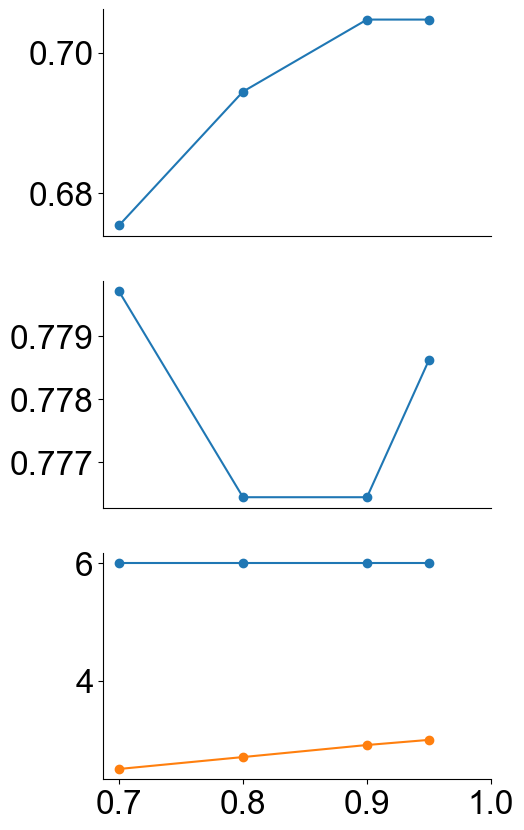

In [85]:
file = open('results/results-eta.pkl', 'rb')
results = pickle.load(file)
file.close()
eta_list, new_IOU_thresholds, coverages, max_confidence_set_sizes, avg_confidence_set_sizes = results

plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(5, 10))

x = np.array(eta_list)
sort_idx = np.argsort(x)

y = np.array(new_IOU_thresholds)
axs[0].plot(x[sort_idx], y[sort_idx], marker='o')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].xaxis.set_visible(False)

y = np.array(coverages)
axs[1].plot(x[sort_idx], y[sort_idx], marker='o')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].xaxis.set_visible(False)

y = np.array(max_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='max')
y = np.array(avg_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='average')
#plt.legend()
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_xticks(np.arange(0.7, 1, 0.1))
plt.show()

# Varying n (number of calibration points)

In [118]:
alpha = 0.2
IOU_threshold = 0.7
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
IOU_threshold_duplicate_mask = 0.9

n_list = [1800, 1200, 600]

In [119]:
for i, n in enumerate(n_list):
    file = open('../data/ftw_predictions/france_test/conformal_ious_more_T_values.pkl', 'rb')
    results_table = pickle.load(file)
    file.close()
    results_table = results_table.sample(n=n, random_state=1)
    IOUs = np.array([np.array(x) for x in results_table["IOUs"]])
    results_table = results_table[['image_number', 'coord']]

    file = open('../data/ftw_predictions/france_test/conformal_ious_test_with_pairwise_IOUs_more_T_values.pkl', 'rb')
    results_table_test = pickle.load(file)
    file.close()
    results_table_test = results_table_test[['image_number', 'coord']]

    save_filename = f'n-{i}'
    p = 1 - np.sum(np.max(IOUs, axis=1) > IOU_threshold) / len(IOUs)
    if p > alpha: 
        print("No set of parameters will allow us to meet the IOU threshold")
        T_confidence_set = T_values
    else:
        T_confidence_set = compute_T_confidence_set(IOUs, T_values, alpha, IOU_threshold)
    compute_pair_ious(results_table, T_confidence_set, save_filename+'-calibration')
    compute_pair_ious(results_table_test, T_confidence_set, save_filename+'-test')

Greedy algorithm output: [0.001 0.06  0.26  0.35  0.58 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [07:03<00:00,  2.17it/s]


Greedy algorithm output: [0.002 0.06  0.24  0.35  0.58 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [07:14<00:00,  2.11it/s]


Greedy algorithm output: [0.001 0.002 0.003 0.01  0.11  0.24  0.31  0.58  0.69  0.73 ]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 917/917 [07:10<00:00,  2.13it/s]


In [124]:
new_IOU_thresholds = []
coverages = []
max_confidence_set_sizes = []
avg_confidence_set_sizes = []

for i, IOU_threshold in enumerate(n_list):
    save_filename = f'n-{i}'
    new_IOU_threshold, coverage, max_confidence_set_size, avg_confidence_set_size = compute_final_results_asymptotic(save_filename, alpha, IOU_threshold_duplicate_mask) 

    new_IOU_thresholds.append(new_IOU_threshold)
    coverages.append(coverage)
    max_confidence_set_sizes.append(max_confidence_set_size)
    avg_confidence_set_sizes.append(avg_confidence_set_size)

# include results from "alpha-0" experiment
results = [[2476]+n_list, [0.70469606]+new_IOU_thresholds, [0.7764449291166848]+coverages, [6]+max_confidence_set_sizes, [2.9051254089422027]+avg_confidence_set_sizes]
file = open(f'results/results-n.pkl', 'wb')
pickle.dump(results, file)
file.close()

for l in results:
    print(l)

[2476, 1800, 1200, 600]
[0.70469606, np.float32(0.69882774), np.float32(0.7006684), np.float32(0.685341)]
[0.7764449291166848, 0.7699018538713195, 0.7797164667393675, 0.8309705561613958]
[6, 5, 5, 10]
[2.9051254089422027, np.float64(2.26608505997819), np.float64(2.191930207197383), np.float64(3.693565976008724)]


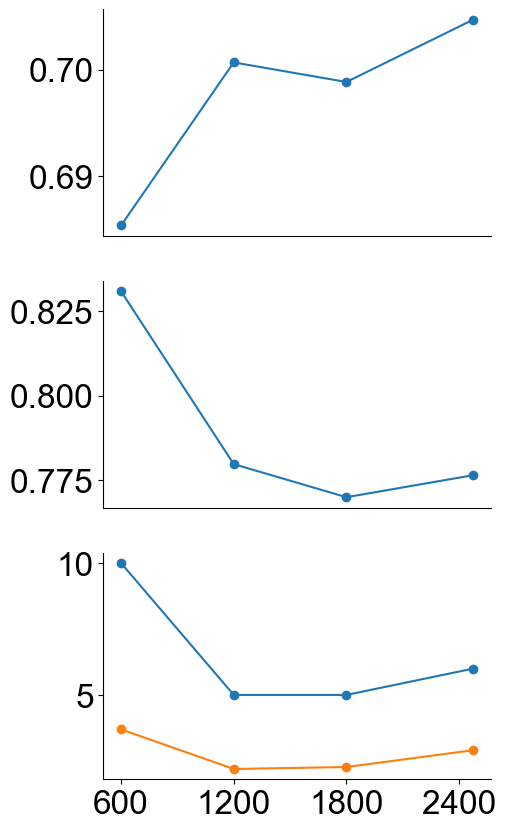

In [126]:
file = open('results/results-n.pkl', 'rb')
results = pickle.load(file)
file.close()
n_list, new_IOU_thresholds, coverages, max_confidence_set_sizes, avg_confidence_set_sizes = results

plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(5, 10))

x = np.array(n_list)
sort_idx = np.argsort(x)

y = np.array(new_IOU_thresholds)
axs[0].plot(x[sort_idx], y[sort_idx], marker='o')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].xaxis.set_visible(False)

y = np.array(coverages)
axs[1].plot(x[sort_idx], y[sort_idx], marker='o')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].xaxis.set_visible(False)

y = np.array(max_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='max')
y = np.array(avg_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='average')
#plt.legend()
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_xticks(np.arange(600, 3000, 600))
plt.show()

# Visualize all results on the same plot

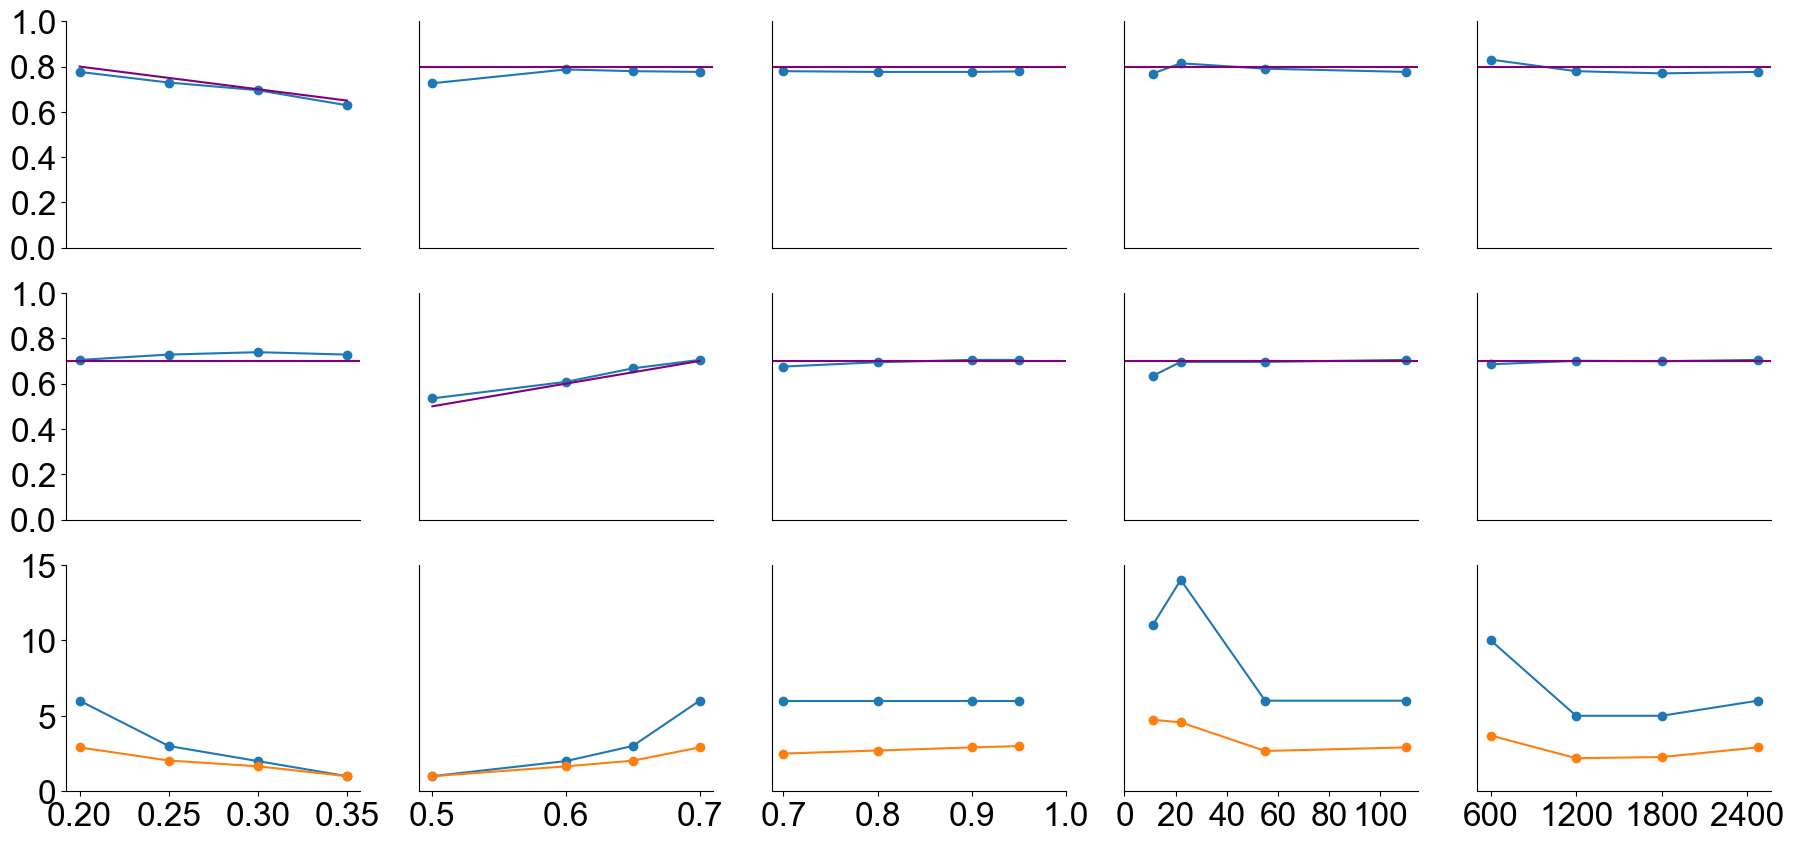

In [159]:
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

fig, axs = plt.subplots(3, 5, sharex='col', sharey='row', figsize=(22, 10))

variables_list = ['alpha', 'tau', 'eta', 'k', 'n']
xticks_list = [np.arange(0.2, 0.4, 0.05), np.arange(0.5, 0.75, 0.1), np.arange(0.7, 1, 0.1), np.arange(0, 120, 20), np.arange(600, 3000, 600)]
for i, variable in enumerate(variables_list):
    file = open(f'results/results-{variable}.pkl', 'rb')
    results = pickle.load(file)
    file.close()
    
    x, new_IOU_thresholds, coverages, max_confidence_set_sizes, avg_confidence_set_sizes = results
    x = np.array(x)
    sort_idx = np.argsort(x)

    y = np.array(coverages)
    axs[0, i].plot(x[sort_idx], y[sort_idx], marker='o')
    if variable == 'alpha':
        a = np.arange(0.2, 0.36, 0.05)
        axs[0, i].plot(a, 1-a, color='purple', label='target coverage')
    else:
        axs[0, i].axhline(0.8, color='purple', label='target coverage')
    #axs[0, i].legend()
    axs[0, i].spines['top'].set_visible(False)
    axs[0, i].spines['right'].set_visible(False)
    axs[0, i].xaxis.set_visible(False)
    if i != 0:
        axs[0, i].yaxis.set_visible(False)
    axs[0, i].set_yticks(np.arange(0, 1.01, 0.2))
    
    y = np.array(new_IOU_thresholds)
    axs[1, i].plot(x[sort_idx], y[sort_idx], marker='o')
    if variable == 'tau':
        a = np.arange(0.5, 0.71, 0.01)
        axs[1, i].plot(a, a, color='purple', label=' ')
    else:
        axs[1, i].axhline(0.7, color='purple', label=' ')
    #axs[1, i].legend()
    axs[1, i].spines['top'].set_visible(False)
    axs[1, i].spines['right'].set_visible(False)
    axs[1, i].xaxis.set_visible(False)
    if i != 0:
        axs[1, i].yaxis.set_visible(False)
    axs[1, i].set_yticks(np.arange(0, 1.01, 0.2))    
    
    y = np.array(max_confidence_set_sizes)
    axs[2, i].plot(x[sort_idx], y[sort_idx], marker='o', label='max')
    y = np.array(avg_confidence_set_sizes)
    axs[2, i].plot(x[sort_idx], y[sort_idx], marker='o', label='average')
    #axs[2, i].legend()
    axs[2, i].spines['top'].set_visible(False)
    axs[2, i].spines['right'].set_visible(False)
    axs[2, i].set_xticks(xticks_list[i])
    axs[2, i].set_yticks(np.arange(0, 16, 5))
    if i != 0:
        axs[2, i].yaxis.set_visible(False)
plt.show()

# Varying n (number of calibration points) - finite sample version

In [105]:
alpha = 0.2
IOU_threshold = 0.7
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
IOU_threshold_duplicate_mask = 0.9

#n_list = [2476, 1800, 1200, 600]
n_list = [600]

In [109]:
def compute_T_ordering(IOUs, T_values, IOU_threshold):
    T_ordering_indices = []
    IOUs_high = (IOUs>IOU_threshold).astype(int)
    while True:
        coverage_by_T = IOUs_high.sum(axis=0)
        if np.max(coverage_by_T) == 0:
            break
        else:
            best_T = np.argmax(coverage_by_T)
            calibration_pixels_covered = np.argwhere(IOUs_high[:, best_T]==1)
            IOUs_high = np.delete(IOUs_high, calibration_pixels_covered, axis=0)
            T_ordering_indices.append(int(best_T))
    T_ordering = T_values[T_ordering_indices]
    return T_ordering

def compute_T_confidence_set_finite_sample(results_table_2, T_ordering, IOU_threshold, alpha, IOU_threshold_duplicate_mask):
    n2 = len(results_table_2)
    pair_to_iou_dicts = np.array(results_table_2["Pred Mask Pair to IOUs"])
    IOUs = np.array([np.array(x) for x in results_table_2["IOUs"]])
    IOUs_high = (IOUs>IOU_threshold).astype(int)
    target_risk = alpha - (1-alpha)/n2
    
    for i in range(len(T_ordering)):
        num_points_covered = 0
        for j in range(n2):
            pair_to_iou = pair_to_iou_dicts[j]
            indices_to_keep = remove_duplicate_masks_finite_sample(list(np.arange(i+1)), pair_to_iou, IOU_threshold_duplicate_mask)
            if np.max(IOUs_high[j][indices_to_keep]) == 1:
                num_points_covered += 1
        risk = 1 - num_points_covered / n2 # fraction of points that have not been covered
        if risk <= target_risk:
            break
    
    T_confidence_set = T_ordering[:i+1]
    
    print("target risk:", target_risk)
    print("final risk:", risk)
    if risk > target_risk:
        print("alpha too small")
    else:
        print("T confidence set:", T_confidence_set)

    return T_confidence_set

def remove_duplicate_masks_finite_sample(indices, pair_to_iou, iou_threshold):
    if len(indices) == 1:
        return indices
    else:
        indices_to_keep = remove_duplicate_masks_finite_sample(indices[:-1], pair_to_iou, iou_threshold)
        for index in indices[:-1]:
            IOU = pair_to_iou[(index, indices[-1])]
            if IOU > iou_threshold:
                return indices_to_keep
        indices_to_keep.append(indices[-1])
        return indices_to_keep

def compute_final_results_finite_sample(save_filename, IOU_threshold, IOU_threshold_duplicate_mask):
    file = open(f'results/field-delineation-{save_filename}-test.pkl', 'rb')
    results_table_test = pickle.load(file)
    file.close()
    max_confidence_set_size = len(results_table_test['IOUs'][0])
    indices = np.arange(max_confidence_set_size)
    results_table_test["Final Mask Indices"] = results_table_test["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_finite_sample(indices, x, iou_threshold=IOU_threshold_duplicate_mask))
    results_table_test["Final Mask Number"] = results_table_test["Final Mask Indices"].apply(lambda x: len(x))
    results_table_test["Final Mask IOUs"] = results_table_test.apply(lambda x: np.array(x["IOUs"])[x["Final Mask Indices"]], axis=1)
    results_table_test["Final Mask max IOU"] = results_table_test["Final Mask IOUs"].map(lambda x: np.max(x))
    results_table_test_high_IOUs = results_table_test[results_table_test["Final Mask max IOU"] > IOU_threshold]
    coverage = len(results_table_test_high_IOUs) / len(results_table_test)
    avg_confidence_set_size = np.mean(results_table_test["Final Mask Number"])

    return coverage, max_confidence_set_size, avg_confidence_set_size

In [108]:
for i, n in enumerate(n_list):
    file = open('../data/ftw_predictions/france_test/conformal_ious_more_T_values.pkl', 'rb')
    results_table = pickle.load(file)
    file.close()
    results_table = results_table.sample(n=n, random_state=1)
    m = int(n/2)
    results_table['calibration_step'] = 'step2'
    results_table.loc[results_table.sample(n=m, random_state=0).index, 'calibration_step'] = 'step1'
    results_table_1 = results_table[results_table['calibration_step'] == 'step1']
    results_table_2 = results_table[results_table['calibration_step'] == 'step2']
    IOUs = np.array([np.array(x) for x in results_table_1["IOUs"]])
    results_table_1 = results_table_1[['image_number', 'coord']]
    results_table_2 = results_table_2[['image_number', 'coord']]

    file = open('../data/ftw_predictions/france_test/conformal_ious_test_with_pairwise_IOUs_more_T_values.pkl', 'rb')
    results_table_test = pickle.load(file)
    file.close()
    results_table_test = results_table_test[['image_number', 'coord']]

    save_filename = f'n-{i}-finite-sample'
    T_ordering = compute_T_ordering(IOUs, T_values, IOU_threshold)
    compute_pair_ious(results_table_2, T_ordering[:20], save_filename+'-calibration')

    file = open(f'results/field-delineation-{save_filename}-calibration.pkl', 'rb')
    results_table_2 = pickle.load(file)
    file.close()
    T_confidence_set = compute_T_confidence_set_finite_sample(results_table_2, T_ordering[:20], IOU_threshold, alpha, IOU_threshold_duplicate_mask)
    
    compute_pair_ious(results_table_test, T_confidence_set, save_filename+'-test')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [02:08<00:00,  2.33it/s]


IndexError: index 22 is out of bounds for axis 1 with size 6

In [ ]:
coverages = []
max_confidence_set_sizes = []
avg_confidence_set_sizes = []

for i, IOU_threshold in enumerate(n_list):
    save_filename = f'n-{i}-finite-sample'
    coverage, max_confidence_set_size, avg_confidence_set_size = compute_final_results_finite_sample(save_filename, IOU_threshold, IOU_threshold_duplicate_mask) 

    coverages.append(coverage)
    max_confidence_set_sizes.append(max_confidence_set_size)
    avg_confidence_set_sizes.append(avg_confidence_set_size)

results = [n_list, coverages, max_confidence_set_sizes, avg_confidence_set_sizes]
file = open(f'results/results-n-finite-sample.pkl', 'wb')
pickle.dump(results, file)
file.close()

for l in results:
    print(l)

In [ ]:
file = open('results/results-n-finite-sample.pkl', 'rb')
results = pickle.load(file)
file.close()
n_list, coverages, max_confidence_set_sizes, avg_confidence_set_sizes = results

plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(5, 10))

x = np.array(n_list)
sort_idx = np.argsort(x)

axs[0].axis('off')

y = np.array(coverages)
axs[1].plot(x[sort_idx], y[sort_idx], marker='o')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].xaxis.set_visible(False)

y = np.array(max_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='max')
y = np.array(avg_confidence_set_sizes)
axs[2].plot(x[sort_idx], y[sort_idx], marker='o', label='average')
#plt.legend()
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_xticks(np.arange(300, 2700, 300))
plt.show()